In [1]:

# analiza podataka
import pandas as pd
import numpy as np

# vizualizacija
import seaborn as sns
import matplotlib.pyplot as plt

# priprema i modeliranje
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB

# evaluacija
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


In [ ]:
files = ["f1.csv", "f2.csv", "f3.csv", "f4.csv"]
dfs = [pd.read_csv(f, sep=";", dtype=str, encoding="utf-8-sig") for f in files]
merged = pd.concat(dfs, ignore_index=True)
merged.to_csv("fuel_data_final.csv", sep=";", index=False, encoding="utf-8-sig")

FileNotFoundError: [Errno 2] No such file or directory: 'f1.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187100 entries, 0 to 1187099
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   obj_id          1187100 non-null  int64 
 1   time            1187100 non-null  object
 2   fuel_lvl        1187100 non-null  int64 
 3   withdrawl_flag  1187100 non-null  int64 
 4   speed           1187100 non-null  int64 
 5   contact_value   1187100 non-null  object
 6   gps_latitude    1187082 non-null  object
 7   gps_longitude   1187082 non-null  object
dtypes: int64(4), object(4)
memory usage: 72.5+ MB


In [ ]:
# Konverzija stupca 'time' u datetime format
df['time'] = pd.to_datetime(df['time'])

# Konverzija koordinata: zamjena zareza točkom i pretvorba u float
df['gps_latitude'] = df['gps_latitude'].str.replace(',', '.').astype(float)
df['gps_longitude'] = df['gps_longitude'].str.replace(',', '.').astype(float)

# Provjera tipova podataka i prvih nekoliko redaka
print(df.dtypes)
display(df.head())

obj_id                     int64
time              datetime64[ns]
fuel_lvl                   int64
withdrawl_flag             int64
speed                      int64
contact_value             object
gps_latitude             float64
gps_longitude            float64
dtype: object


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
0,2484,2025-12-08 13:39:00,144,0,0,-,45.792643,17.001076
1,2484,2025-12-08 13:40:00,144,0,0,-,45.792643,17.001076
2,2484,2025-12-08 13:41:00,144,0,29,-,45.793414,17.316811
3,2484,2025-12-08 13:42:00,144,0,37,-,45.801079,16.994503
4,2484,2025-12-08 13:43:00,144,0,3,-,45.802589,16.995177


In [ ]:
# Provjera jedinstvenih vrijednosti i njihove učestalosti
print("Jedinstvene vrijednosti u contact_value:")
print(df['contact_value'].unique())

print("\nBroj pojavljivanja svake vrijednosti:")
print(df['contact_value'].value_counts())

# Provjera nedostajućih vrijednosti
print("\nBroj null vrijednosti:", df['contact_value'].isnull().sum())

Jedinstvene vrijednosti u contact_value:
['-' 'Neaktivan' 'Aktivan']

Broj pojavljivanja svake vrijednosti:
contact_value
Aktivan      668709
Neaktivan    348891
-            169500
Name: count, dtype: int64

Broj null vrijednosti: 0


In [ ]:
display(df[df['contact_value'] == 'Neaktivan'].head())

,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
2280,7935,2025-12-15 18:49:00,398,0,0,Neaktivan,45.808984,15.869859
2281,7935,2025-12-15 18:50:00,398,0,0,Neaktivan,45.808984,15.869859
2282,7935,2025-12-15 18:51:00,398,0,0,Neaktivan,45.808984,15.869859
2283,7935,2025-12-15 18:52:00,398,0,0,Neaktivan,45.808984,15.869859
2284,7935,2025-12-15 18:53:00,398,0,0,Neaktivan,45.808984,15.869859


/tmp/ipykernel_2490/851883856.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df.sort_values('fuel_lvl'), x='fuel_bins', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_2490/851883856.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='withdrawl_flag', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_2490/851883856.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='contact_value', ax=axes[1, 0], palette='coolwarm')
/tmp/ipykernel_2490/851883856.py:24: FutureWarning: 

Passing `palette` without assigni

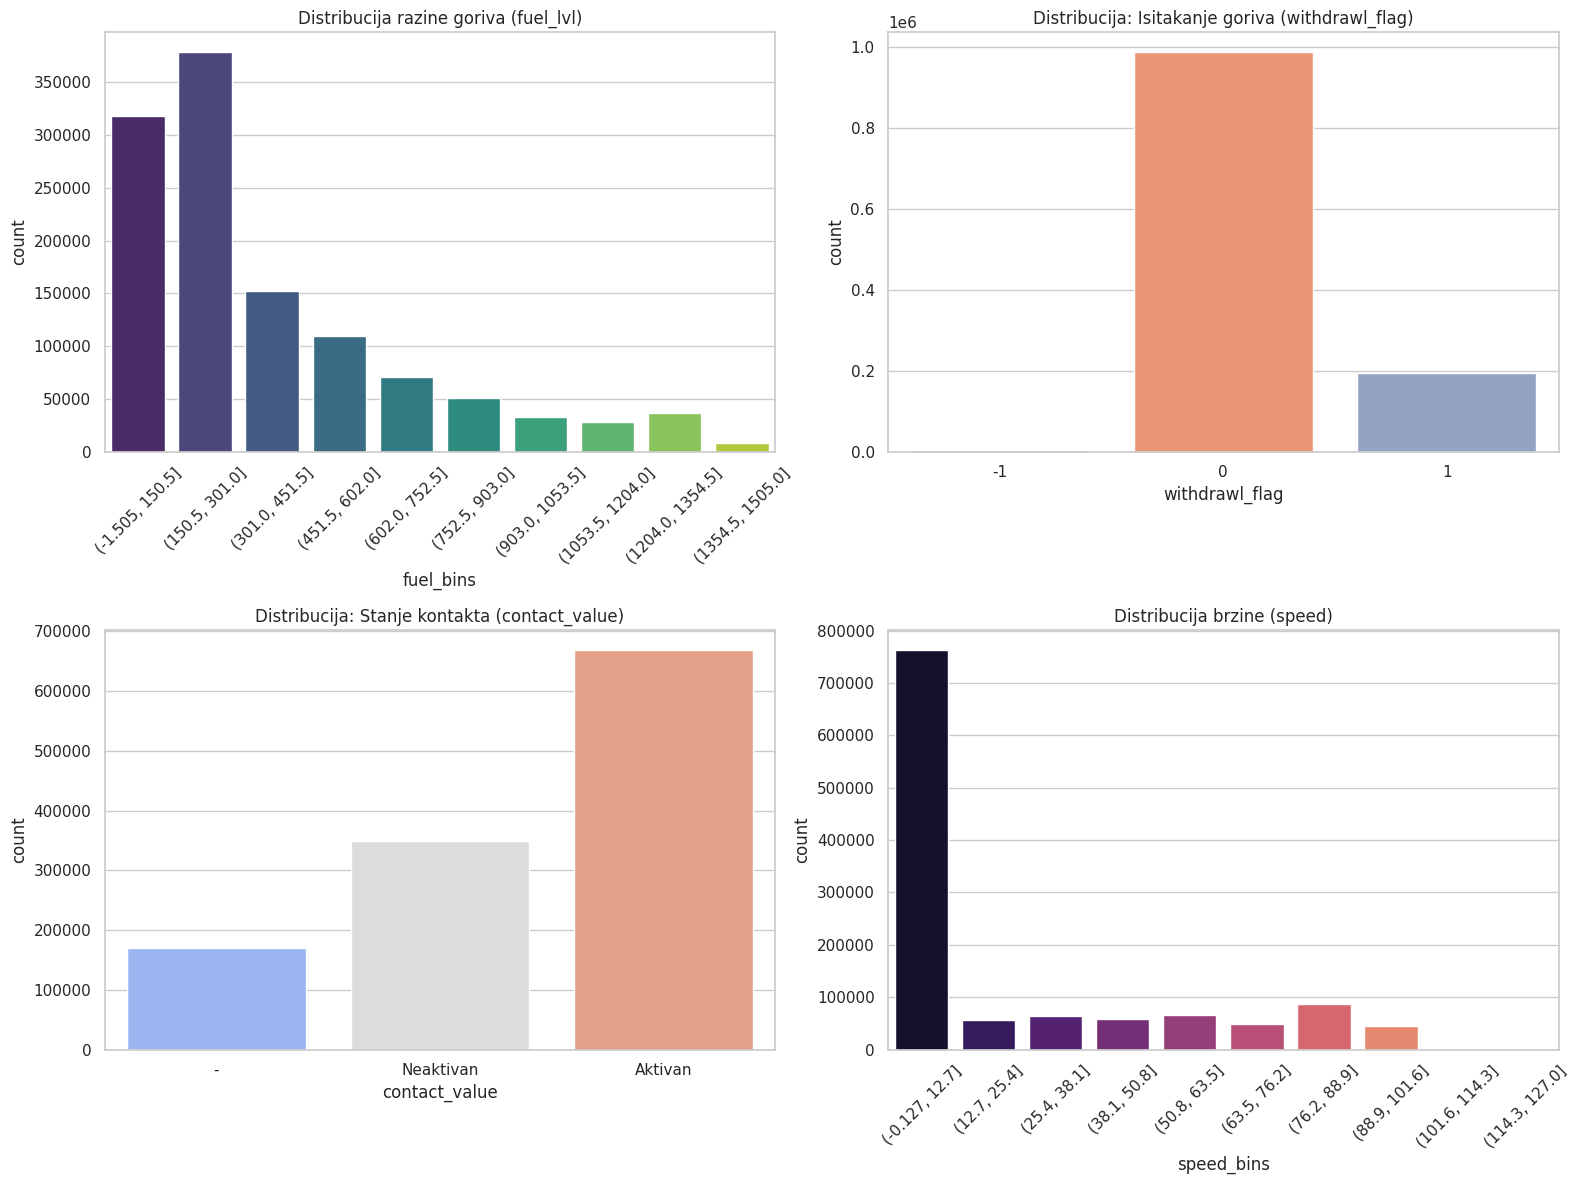

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Postavljanje teme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribucija fuel_lvl (grupirano u 10 intervala)
df['fuel_bins'] = pd.cut(df['fuel_lvl'], bins=10).astype(str)
sns.countplot(data=df.sort_values('fuel_lvl'), x='fuel_bins', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribucija razine goriva (fuel_lvl)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Distribucija withdrawl_flag
sns.countplot(data=df, x='withdrawl_flag', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Distribucija: Isitakanje goriva (withdrawl_flag)')

# 3. Distribucija contact_value
sns.countplot(data=df, x='contact_value', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Distribucija: Stanje kontakta (contact_value)')

# 4. Distribucija speed (grupirano u 10 intervala)
df['speed_bins'] = pd.cut(df['speed'], bins=10).astype(str)
sns.countplot(data=df.sort_values('speed'), x='speed_bins', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Distribucija brzine (speed)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Čišćenje privremenih stupaca
df.drop(columns=['fuel_bins', 'speed_bins'], inplace=True)

plt.tight_layout()
plt.show()

In [ ]:
# Pronalaženje redaka gdje je withdrawl_flag -1
withdrawl_minus_1 = df[df['withdrawl_flag'] == -1]

print(f"Broj redaka s withdrawl_flag = -1: {len(withdrawl_minus_1)}")
display(withdrawl_minus_1.head())

Broj redaka s withdrawl_flag = -1: 4481


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
3990,13886,2025-12-19 11:25:00,130,-1,0,Neaktivan,45.897835,16.201183
3991,13886,2025-12-19 11:26:00,125,-1,0,Neaktivan,45.897835,16.201191
3992,13886,2025-12-19 11:27:00,123,-1,0,Neaktivan,45.897849,16.201202
3993,13886,2025-12-19 11:27:00,123,-1,0,Neaktivan,45.897849,16.201202
7590,28161,2025-12-15 11:53:00,253,-1,8,Aktivan,49.581093,14.568910


In [ ]:
# Analiza korelacije withdrawl_flag-a s promjenom razine goriva
print("Prosječna razina goriva po withdrawl_flag:")
display(df.groupby('withdrawl_flag')['fuel_lvl'].mean())

# Provjera stanja kontakta za vrijednost -1
print("\nStanje kontakta za withdrawl_flag = -1:")
display(df[df['withdrawl_flag'] == -1]['contact_value'].value_counts())

Prosječna razina goriva po withdrawl_flag:


,fuel_lvl
withdrawl_flag,
-1,310.426021
0,346.644882
1,503.284971



Stanje kontakta za withdrawl_flag = -1:


,count
contact_value,
Aktivan,1847
Neaktivan,1481
-,1153


In [ ]:
# Definiranje značajki
numerical_features = ['fuel_lvl', 'speed', 'gps_latitude', 'gps_longitude']
categorical_features = ['contact_value']

# Pipeline za numeričke značajke: Imputacija medijanom + Standardizacija
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline za kategoričke značajke: Imputacija najčešćom vrijednošću + One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Spajanje u ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('cat', cat_transformer, categorical_features)
    ]
)

# Prikaz preprocesora
print("Preprocessing pipeline je definiran.")
display(preprocessor)

Preprocessing pipeline je definiran.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['fuel_lvl', 'speed', 'gps_latitude',
                                  'gps_longitude']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['contact_value'])])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187100 entries, 0 to 1187099
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   obj_id          1187100 non-null  int64         
 1   time            1187100 non-null  datetime64[ns]
 2   fuel_lvl        1187100 non-null  int64         
 3   withdrawl_flag  1187100 non-null  int64         
 4   speed           1187100 non-null  int64         
 5   contact_value   1187100 non-null  object        
 6   gps_latitude    1187082 non-null  float64       
 7   gps_longitude   1187082 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 72.5+ MB


In [ ]:
# Definiranje značajki (X) i ciljne varijable (y)
X = df.drop(columns=['withdrawl_flag', 'time', 'obj_id'])
y = df['withdrawl_flag']

# Podjela na trening i test skup (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Veličina skupa za treniranje: {X_train.shape[0]} redaka")
print(f"Veličina skupa za testiranje: {X_test.shape[0]} redaka")

Veličina skupa za treniranje: 830970 redaka
Veličina skupa za testiranje: 356130 redaka


In [ ]:
# Uzorkovanje 200,000 zapisa
df_sample_200 = df.sample(n=200000, random_state=42)
X_s2 = df_sample_200.drop(columns=['withdrawl_flag', 'time', 'obj_id'])
y_s2 = df_sample_200['withdrawl_flag']

# Podjela na trening i test (70/30)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_s2, y_s2, test_size=0.30, random_state=42, stratify=y_s2)

# Definiranje i treniranje modela
nb_pipeline_200 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

nb_pipeline_200.fit(X_train_2, y_train_2)

# Predviđanje i evaluacija
y_pred_200 = nb_pipeline_200.predict(X_test_2)
y_proba_200 = nb_pipeline_200.predict_proba(X_test_2)

# Izračun metrika
accuracy = accuracy_score(y_test_2, y_pred_200)
precision = precision_score(y_test_2, y_pred_200, average='weighted', zero_division=0)
recall = recall_score(y_test_2, y_pred_200, average='weighted')
f1 = f1_score(y_test_2, y_pred_200, average='weighted')
roc_auc = roc_auc_score(y_test_2, y_proba_200, multi_class='ovr')

# Prikaz rezultata u traženom formatu
print("--- Rezultati Naivnog Bayesa ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_200))

--- Rezultati Naivnog Bayesa ---
Accuracy:  0.7295
Precision: 0.8093
Recall:    0.7295
F1-score:  0.7561
ROC AUC:   0.7540

Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       230
           0       0.91      0.75      0.82     49890
           1       0.33      0.63      0.43      9880

    accuracy                           0.73     60000
   macro avg       0.41      0.46      0.42     60000
weighted avg       0.81      0.73      0.76     60000



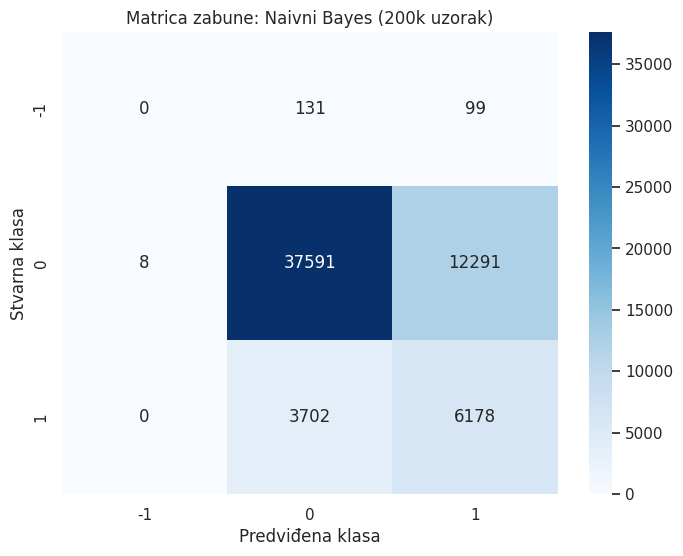

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Definiranje oznaka klasa na temelju y_test_2
labels = sorted(y_test_2.unique())

# Izračun matrice zabune
cm_nb_200 = confusion_matrix(y_test_2, y_pred_200, labels=labels)

# Vizualizacija
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb_200, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matrica zabune: Naivni Bayes (200k uzorak)')
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.show()

Naivni Bayes ne funkcionira dobro sa neuravnoteženim podacima poput onih u withdrawl_flag gdje klasa -1 ima samo 1344 primjera.Pokušati ćemo sa Random Forest algoritmom.

--- Rezultati Random Foresta ---
Accuracy:  0.9090
Precision: 0.9036
Recall:    0.9090
F1-score:  0.9041
ROC AUC:   0.9031

Classification Report:
              precision    recall  f1-score   support

          -1       0.56      0.20      0.29       230
           0       0.93      0.97      0.95     49890
           1       0.79      0.63      0.70      9880

    accuracy                           0.91     60000
   macro avg       0.76      0.60      0.65     60000
weighted avg       0.90      0.91      0.90     60000



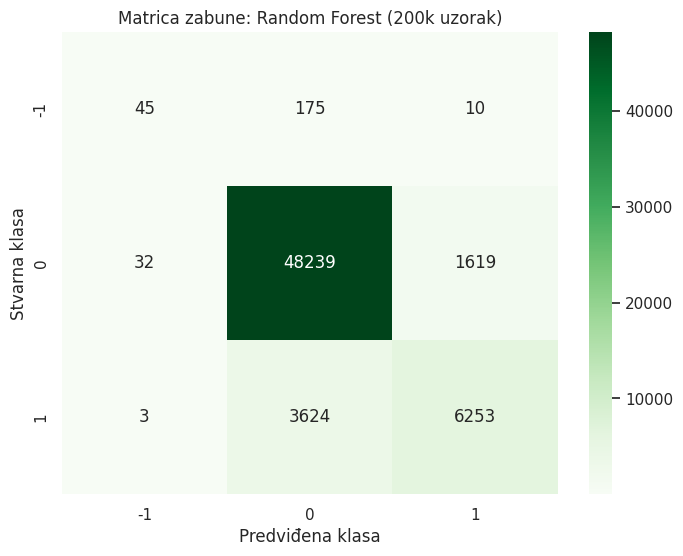

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Definiranje i treniranje Random Forest modela na 200k uzorku
rf_pipeline_200 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline_200.fit(X_train_2, y_train_2)

# Predviđanje i evaluacija
y_pred_rf_200 = rf_pipeline_200.predict(X_test_2)
y_proba_rf_200 = rf_pipeline_200.predict_proba(X_test_2)

# Izračun metrika
accuracy_rf = accuracy_score(y_test_2, y_pred_rf_200)
precision_rf = precision_score(y_test_2, y_pred_rf_200, average='weighted', zero_division=0)
recall_rf = recall_score(y_test_2, y_pred_rf_200, average='weighted')
f1_rf = f1_score(y_test_2, y_pred_rf_200, average='weighted')
roc_auc_rf = roc_auc_score(y_test_2, y_proba_rf_200, multi_class='ovr')

# Prikaz rezultata
print("--- Rezultati Random Foresta ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"ROC AUC:   {roc_auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_rf_200))

# Matrica zabune
plt.figure(figsize=(8, 6))
cm_rf_200 = confusion_matrix(y_test_2, y_pred_rf_200, labels=labels)
sns.heatmap(cm_rf_200, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Matrica zabune: Random Forest (200k uzorak)')
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:24:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Rezultati XGBoosta ---
Accuracy:  0.8846
Precision: 0.8752
Recall:    0.8846
F1-score:  0.8745
ROC AUC:   0.9140

Classification Report:
              precision    recall  f1-score   support

          -1       0.74      0.09      0.16       230
           0       0.90      0.96      0.93     49890
           1       0.73      0.50      0.60      9880

    accuracy                           0.88     60000
   macro avg       0.79      0.52      0.56     60000
weighted avg       0.88      0.88      0.87     60000



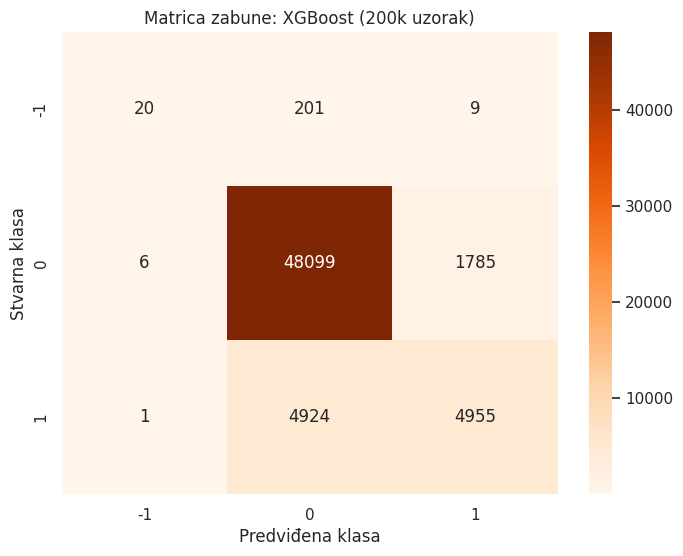

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost zahtijeva da klase počinju od 0 (npr. 0, 1, 2)
le_200 = LabelEncoder()
y_train_xgb_200 = le_200.fit_transform(y_train_2)
y_test_xgb_200 = le_200.transform(y_test_2)

# Kreiranje XGBoost modela u pipelineu
xgb_pipeline_200 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

# Treniranje
xgb_pipeline_200.fit(X_train_2, y_train_xgb_200)

# Predviđanje i vjerojatnosti
y_pred_xgb_200 = xgb_pipeline_200.predict(X_test_2)
y_proba_xgb_200 = xgb_pipeline_200.predict_proba(X_test_2)

# Izračun metrika
accuracy_xgb = accuracy_score(y_test_xgb_200, y_pred_xgb_200)
precision_xgb = precision_score(y_test_xgb_200, y_pred_xgb_200, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test_xgb_200, y_pred_xgb_200, average='weighted')
f1_xgb = f1_score(y_test_xgb_200, y_pred_xgb_200, average='weighted')
roc_auc_xgb = roc_auc_score(y_test_xgb_200, y_proba_xgb_200, multi_class='ovr')

# Prikaz rezultata
print("--- Rezultati XGBoosta ---")
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-score:  {f1_xgb:.4f}")
print(f"ROC AUC:   {roc_auc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_xgb_200, y_pred_xgb_200, target_names=[str(c) for c in le_200.classes_]))

# Matrica zabune
plt.figure(figsize=(8, 6))
cm_xgb_200 = confusion_matrix(y_test_xgb_200, y_pred_xgb_200)
sns.heatmap(cm_xgb_200, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_200.classes_, yticklabels=le_200.classes_)
plt.title('Matrica zabune: XGBoost (200k uzorak)')
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.show()

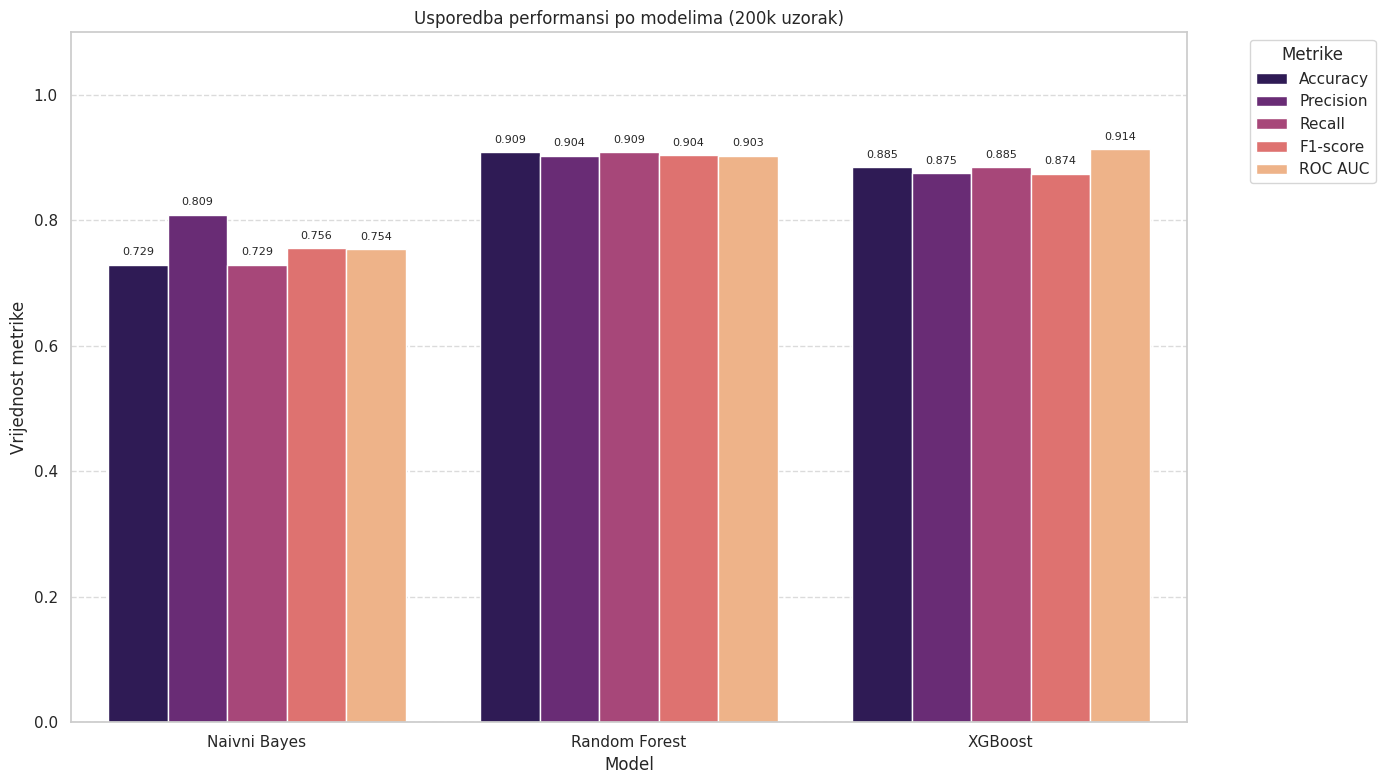

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Osiguravanje da su podaci u ispravnom formatu za vizualizaciju
comparison_data = {
    'Model': ['Naivni Bayes', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_rf, precision_xgb],
    'Recall': [recall, recall_rf, recall_xgb],
    'F1-score': [f1, f1_rf, f1_xgb],
    'ROC AUC': [roc_auc, roc_auc_rf, roc_auc_xgb]
}
df_comparison = pd.DataFrame(comparison_data)
df_melted = df_comparison.melt(id_vars='Model', var_name='Metrika', value_name='Vrijednost')

# Vizualizacija s modelima na X-osi prema vašem kodu
plt.figure(figsize=(14, 8))
sns.barplot(data=df_melted, x='Model', y='Vrijednost', hue='Metrika', palette='magma')

plt.title('Usporedba performansi po modelima (200k uzorak)')
plt.ylim(0, 1.1)
plt.ylabel('Vrijednost metrike')
plt.xlabel('Model')
plt.legend(title='Metrike', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Dodavanje vrijednosti iznad stupaca
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points',
                       fontsize=8,
                       rotation=0)

plt.tight_layout()
plt.show()